# TURRET Kalman Filter Analysis Notebook

## Overview

Comprehensive analysis notebook for TURRET captured aircraft tracking and Kalman filter prediction data.

### Sections

1. **Setup and Imports**
2. **Data Loading** - Load captured session data
3. **Data Exploration** - Basic statistics and data quality
4. **Aircraft Tracking Analysis** - Track trajectories and continuity
5. **Kalman Filter Performance** - Covariance, errors, state transitions
6. **Statistical Analysis** - Aircraft counts, rates, stability
7. **Temporal Analysis** - Update intervals, timing, anomalies
8. **Configuration Analysis** - Compare configs and generate recommendations

### Setup

Before running:
- Activate the virtual environment: `source /home/leon/DEV/DOCKER/TURRET/notebooks/venv/bin/activate`
- Ensure capture data exists in the `captures/` directory

In [113]:
# Setup and Imports
import os
import sys
from pathlib import Path
from datetime import datetime

# Add modules to path
module_path = str(Path.cwd() / 'modules')
if module_path not in sys.path:
    sys.path.insert(0, module_path)

# Import analysis modules
from modules.data_loader import DataLoader, create_data_loader
from modules.analysis import KalmanAnalysis, kalman_analysis
from modules.visualization import KalmanVisualizer, kalman_visualizer

# Core data science
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print('Setup complete!')
print(f'Module path: {module_path}')
print(f'Current directory: {Path.cwd()}')

Setup complete!
Module path: /home/leon/DEV/DOCKER/TURRET/notebooks/kalman-tuning/modules
Current directory: /home/leon/DEV/DOCKER/TURRET/notebooks/kalman-tuning


In [114]:
# Define captures directory
captures_dir = os.path.abspath(os.path.join('..', '..', 'captures'))

print(f'Captures directory: {captures_dir}')
print(f'Exists: {os.path.exists(captures_dir)}')

# Create data loader
data_loader = create_data_loader(captures_dir)
print('Data loader created!')

Captures directory: /home/leon/DEV/DOCKER/TURRET/captures
Exists: True
Data loader created!


## 1. Data Loading

Load captured data from the TURRET CSV storage backend.

In [115]:
# Find available dates
available_dates = data_loader.find_available_dates()
print('Available dates:')
for date in available_dates:
    print(f'  - {date}')

# Find sessions for latest date
if available_dates:
    latest_date = available_dates[0]
    sessions = data_loader.find_sessions_for_date(latest_date)
    print(f'Sessions for {latest_date}:')
    for session in sessions:
        print(f'  - {os.path.basename(session)}')

Available dates:
  - 2026-08-27
  - 2026-08-26
  - 2026-08-25
  - 2026-08-24
Sessions for 2026-08-27:
  - 2026-08-27_16-08-38_session_0000
  - 2026-08-27_15-55-27_session_0000


In [116]:
# Load all data
print('Loading data...')
predictions, opensky, statistics, metadata_list = data_loader.load_all_data(limit=1)

print(f'Predictions: {len(predictions)} records')
print(f'OpenSky: {len(opensky)} records')
print(f'Statistics: {len(statistics)} records')
print(f'Sessions: {len(metadata_list)}')

# Show sample data
print('=== Predictions Sample ===')
display(predictions.head(3))

print('=== OpenSky Sample ===')
display(opensky.head(3))

Loading data...
Error loading /home/leon/DEV/DOCKER/TURRET/captures/2026-08-27/2026-08-27_16-08-38_session_0000/statistics.csv: No columns to parse from file
Predictions: 10616 records
OpenSky: 9725 records
Statistics: 0 records
Sessions: 1
=== Predictions Sample ===


,timestamp,frame_index,session_id,callsign,latitude,longitude,baro_altitude,velocity,true_track,vertical_rate,covariance_lat,covariance_lon,covariance_alt,state,v_north,v_east
0,1.787840e+09,2,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,EJU67FD,44.357066,1.737751,11887.200000,184.32,238.35,0.0,1.469219e-07,2.874193e-07,968.097994,tracking,-96.718045,-156.905966
1,1.787840e+09,2,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,EJU45FH,44.036886,0.807399,9010.483218,202.86,148.16,9.1,1.468801e-07,2.842505e-07,967.839388,tracking,-172.334561,107.018591
2,1.787840e+09,2,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,VLG415M,43.925521,1.044124,10660.380000,195.26,173.34,0.0,1.468649e-07,2.831620e-07,967.745371,tracking,-193.942358,22.645736


=== OpenSky Sample ===


,timestamp,frame_index,session_id,callsign,latitude,longitude,baro_altitude,velocity,true_track,vertical_rate,on_ground,v_north,v_east
0,1.787840e+09,1,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,EJU67FD,44.3596,1.7435,11887.20,184.32,238.35,0.0,False,-96.718045,-156.905966
1,1.787840e+09,1,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,EJU45FH,44.0414,0.8035,8983.98,202.86,148.16,9.1,False,-172.334561,107.018591
2,1.787840e+09,1,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,VLG415M,43.9306,1.0433,10660.38,195.26,173.34,0.0,False,-193.942358,22.645736


In [117]:
# Get combined summary
summary = data_loader.get_combined_summary(predictions, opensky, statistics, metadata_list)

print(f'Sessions: {summary["num_sessions"]}')
print(f'Total predictions: {summary["total_predictions"]}')
print(f'Unique callsigns: {summary["unique_callsigns_predictions"]}')
print(f'States: {summary["state_distribution"]}')

# Kalman configs
for i, config in enumerate(summary['kalman_configs']):
    print(f'Config {i+1}:')
    for k, v in config.items():
        print(f'  {k}: {v}')

Sessions: 1
Total predictions: 10616
Unique callsigns: 53
States: {'tracking': 10616}
Config 1:
  data_update_interval: 30.0
  prediction_interval: 2.0
  max_measurement_age: 60.0
  position_process_noise: 100.0
  velocity_process_noise: 200.0
  position_measurement_noise: 20.0


## 2. Data Exploration

Basic statistics and data quality analysis.

In [118]:
# Basic statistics
pred_stats = kalman_analysis.get_basic_statistics(predictions)
os_stats = kalman_analysis.get_basic_statistics(opensky)

print('=== Predictions Statistics ===')
for col, stats in list(pred_stats.items())[:5]:
    print(f'{col}: mean={stats["mean"]:.2f}, std={stats["std"]:.2f}')

print('=== OpenSky Statistics ===')
for col, stats in list(os_stats.items())[:5]:
    print(f'{col}: mean={stats["mean"]:.2f}, std={stats["std"]:.2f}')

=== Predictions Statistics ===
timestamp: mean=1787840036.55, std=175.81
frame_index: mean=158.89, std=87.88
latitude: mean=43.79, std=0.42
longitude: mean=1.36, std=0.54
baro_altitude: mean=8560.01, std=3909.84
=== OpenSky Statistics ===
timestamp: mean=1787840015.92, std=167.27
frame_index: mean=148.57, std=83.61
latitude: mean=43.77, std=0.43
longitude: mean=1.36, std=0.57
baro_altitude: mean=8605.07, std=3854.10


In [119]:
# Identify data gaps
pred_gaps = kalman_analysis.identify_data_gaps(predictions)
os_gaps = kalman_analysis.identify_data_gaps(opensky)

print('=== Predictions Gaps ===')
print(f'Total records: {pred_gaps["total_records"]}')
print(f'Missing values: {pred_gaps["total_missing_values"]}')
print(f'Avg time between records: {pred_gaps["avg_time_between_records"]:.4f}s')
print(f'Max gap: {pred_gaps["max_gap"]:.4f}s')
print(f'Gaps > 1s: {pred_gaps["gaps_greater_than_1s"]}')
print(f'Gaps > 5s: {pred_gaps["gaps_greater_than_5s"]}')
print(f'Gaps > 10s: {pred_gaps["gaps_greater_than_10s"]}')

=== Predictions Gaps ===
Total records: 10616
Missing values: 0
Avg time between records: 0.0577s
Max gap: 2.0013s
Gaps > 1s: 306
Gaps > 5s: 0
Gaps > 10s: 0


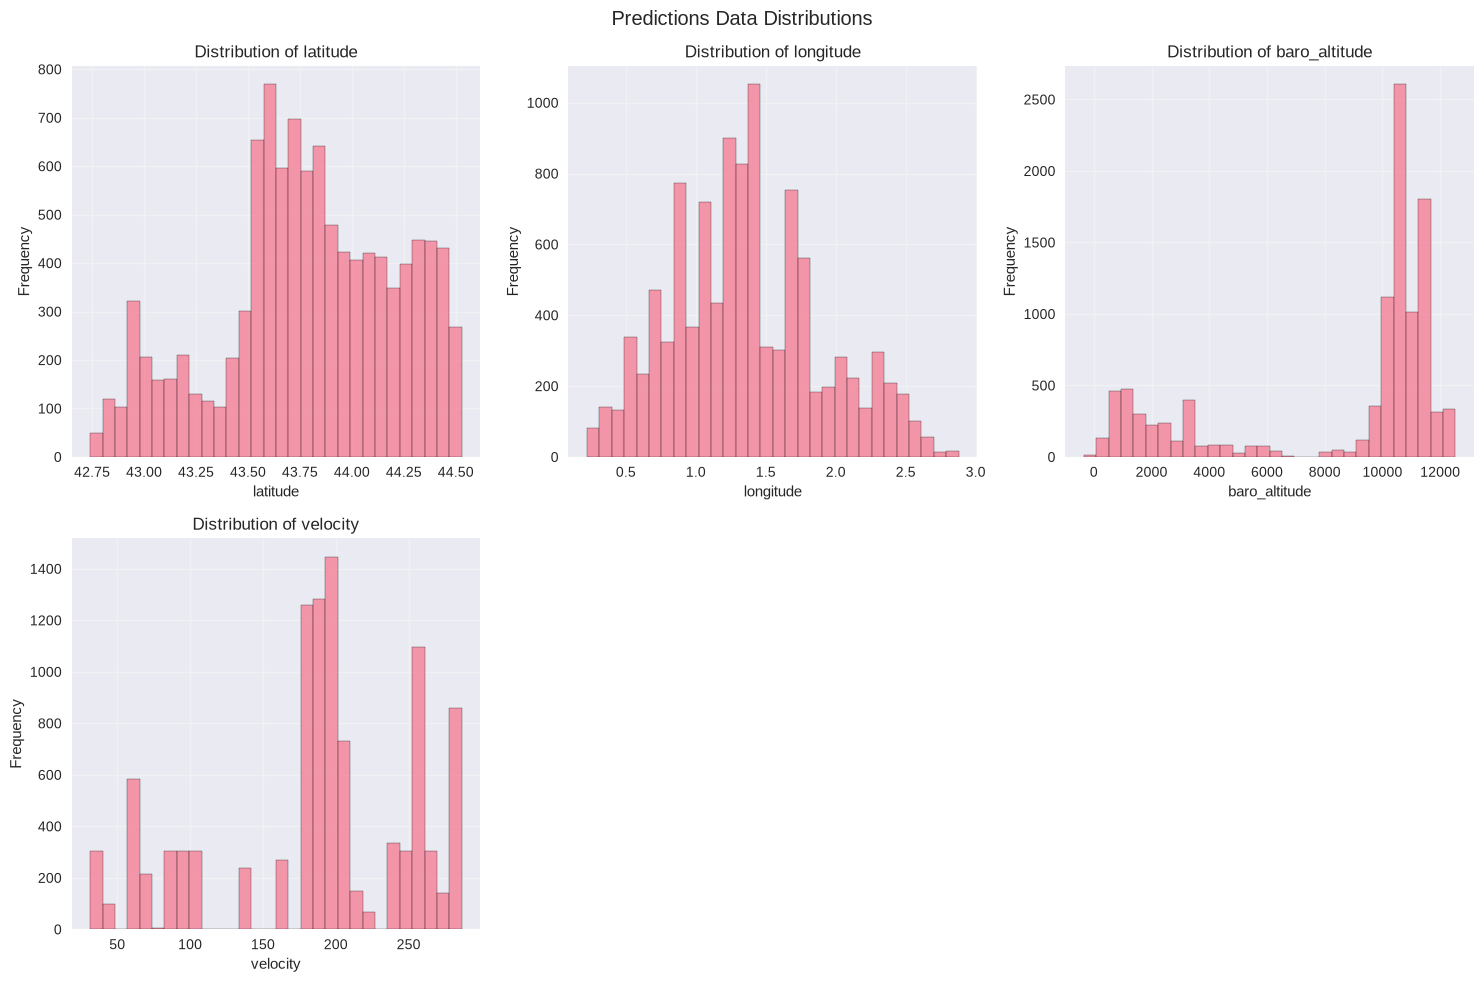

In [120]:
# Plot distributions
key_cols = ['latitude', 'longitude', 'baro_altitude', 'velocity']
plot_cols = [c for c in key_cols if c in predictions.columns]

fig, axes = kalman_visualizer.plot_distribution_histograms(predictions, plot_cols, bins=30)
plt.suptitle('Predictions Data Distributions')
plt.tight_layout()
plt.show()

## 3. Aircraft Tracking Analysis

Track individual aircraft and analyze trajectories.

In [121]:
# Get trajectories
prediction_trajectories = kalman_analysis.get_aircraft_trajectories(predictions)
print(f'Found {len(prediction_trajectories)} aircraft trajectories')

# Show first few
for callsign in list(prediction_trajectories.keys())[:5]:
    print(f'{callsign}: {len(prediction_trajectories[callsign])} predictions')

Found 53 aircraft trajectories
EJU67FD: 307 predictions
EJU45FH: 307 predictions
VLG415M: 306 predictions
HKH1: 59 predictions
AIB01GM: 306 predictions


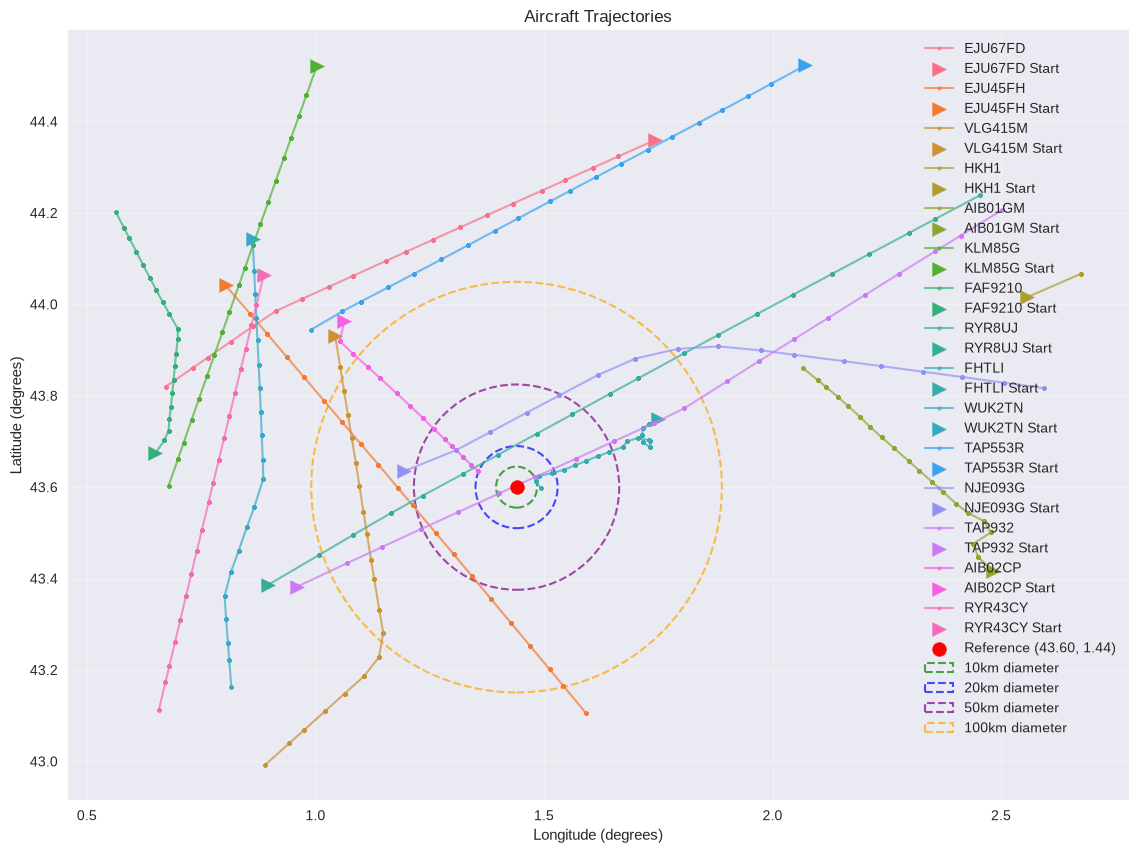

In [122]:
# Plot trajectories with reference point and range circles

if prediction_trajectories:
    sample_callsigns = list(prediction_trajectories.keys())[:min(15, len(prediction_trajectories))]
    sample_preds = opensky[opensky['callsign'].isin(sample_callsigns)]
    
    fig, ax = kalman_visualizer.plot_aircraft_trajectories(
        sample_preds, callsigns=sample_callsigns, figsize=(14, 10)
    )
    
    # Set equal aspect ratio so circles don't appear as ellipses
    ax.set_aspect('equal')
    
    # Reference point (Toulouse area)
    ref_lat = 43.60
    ref_lon = 1.44
    
    # Plot reference point
    ax.scatter(ref_lon, ref_lat, color='red', s=100, zorder=10, label='Reference (43.60, 1.44)')
    
    # Draw concentric circles with different diameters (10km, 20km, 50km, 100km)
    # Earth radius in km, 1 degree of lat/lon ~ 111.32 km
    km_per_degree = 111.32
    
    # Diameters in km and their corresponding radii in degrees
    diameters_km = [10, 20, 50, 100]
    colors = ['green', 'blue', 'purple', 'orange']
    labels = [f'{d}km diameter' for d in diameters_km]
    
    for diameter_km, color, label in zip(diameters_km, colors, labels):
        radius_km = diameter_km / 2
        radius_deg = radius_km / km_per_degree
        
        # Create circle patch
        circle = plt.Circle((ref_lon, ref_lat), radius_deg, 
                           fill=False, edgecolor=color, linestyle='--', 
                           linewidth=1.5, alpha=0.7, label=label)
        ax.add_patch(circle)
    
    # Adjust legend to include circles
    ax.legend(loc='best')
    
    plt.show()

In [ ]:
callsigns = opensky['callsign'].unique()
selected_callsign = callsigns[0]
selected_callsign = "TAP932"

In [124]:
# Track continuity analysis
continuity_results = []
for callsign, trajectory in prediction_trajectories.items():
    metrics = kalman_analysis.calculate_track_continuity(trajectory)
    continuity_results.append(metrics)

# Summary
if continuity_results:
    coverages = [m.track_coverage for m in continuity_results]
    print(f'Average track coverage: {np.mean(coverages):.2%}')
    print(f'Median track coverage: {np.median(coverages):.2%}')
    print(f'Average frames per aircraft: {np.mean([m.total_frames for m in continuity_results]):.1f}')

Average track coverage: 100.00%
Median track coverage: 100.00%
Average frames per aircraft: 200.3


In [125]:
# Track accuracy analysis
accuracy_metrics = kalman_analysis.analyze_track_accuracy(predictions, opensky)
print(f'Aircraft with comparison data: {len(accuracy_metrics)}')

# Overall error statistics
error_stats = kalman_analysis.calculate_prediction_error_statistics(predictions, opensky)
if error_stats:
    print(f'\nRMSE Position: {error_stats["rmse_position_m"]:.2f}m')
    print(f'MAE Position: {error_stats["mae_position_m"]:.2f}m')
    print(f'RMSE Altitude: {error_stats["rmse_altitude_m"]:.2f}m')
    print(f'RMSE Velocity: {error_stats["rmse_velocity_knots"]:.2f} knots')

Aircraft with comparison data: 51

RMSE Position: 24245.21m
MAE Position: 18324.71m
RMSE Altitude: 478.15m
RMSE Velocity: 24.02 knots


In [126]:
# Interactive 3D trajectory plot
# Try to import plotly for interactive visualization
try:
    import plotly.graph_objects as go
    from modules.visualization import plot_3d_trajectory_interactive
    has_plotly = True
except ImportError:
    has_plotly = False
    print('Plotly not available. Install with: pip install plotly')

if prediction_trajectories:
    # sample_callsign = list(prediction_trajectories.keys())[0]
    # sample_callsign = "JAF6LD"
    preds = prediction_trajectories[selected_callsign]
    measurements = opensky[opensky['callsign']==selected_callsign]
    
    if has_plotly:
        # Use interactive 3D plot with Plotly
        fig = plot_3d_trajectory_interactive(preds, measurements, callsign=selected_callsign)
        if fig:
            fig.show()
    else:
        # Fall back to matplotlib 3D plot
        fig = kalman_visualizer.plot_3d_trajectory(preds, callsign=selected_callsign)
        plt.show()

## 4. Kalman Filter Performance

Analyze covariance, prediction errors, and state transitions.

In [127]:
# Covariance convergence analysis
covariance_results = []
for callsign, trajectory in prediction_trajectories.items():
    if len(trajectory) >= 5:
        result = kalman_analysis.analyze_covariance_convergence(trajectory)
        covariance_results.append(result)

print(f'Analyzed {len(covariance_results)} aircraft')

# Summary
if covariance_results:
    rates = [r.convergence_rate for r in covariance_results]
    steady = [r.steady_state_reached for r in covariance_results]
    print(f'Avg convergence rate: {np.mean(rates):.2%}')
    print(f'Steady state reached: {sum(steady)}/{len(steady)} ({sum(steady)/len(steady)*100:.1f}%)')

Analyzed 53 aircraft
Avg convergence rate: -18974.27%
Steady state reached: 0/53 (0.0%)


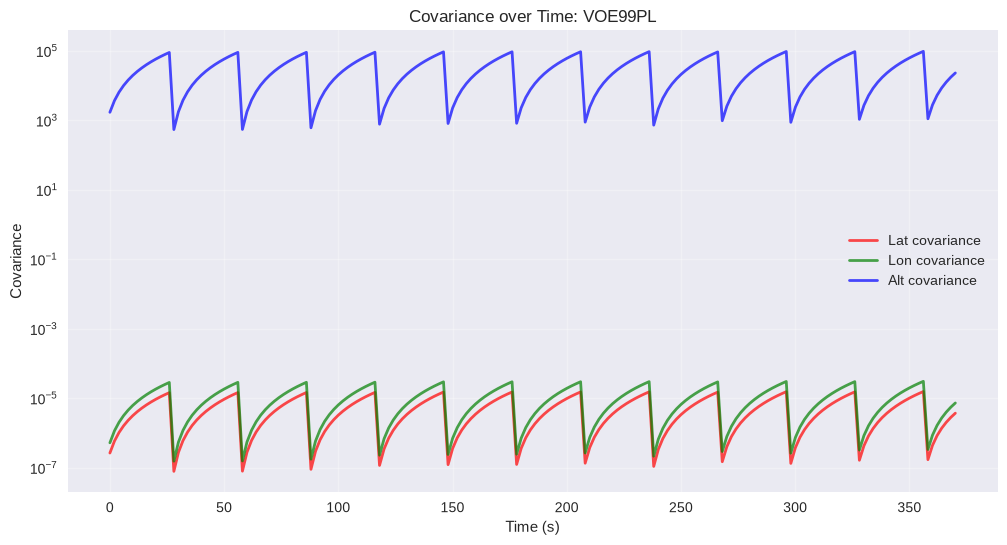

In [128]:
# Plot covariance
if covariance_results:
    best_idx = np.argmax([r.convergence_rate for r in covariance_results])
    best_callsign = covariance_results[best_idx].callsign
    best_traj = prediction_trajectories[best_callsign]
    
    fig, ax = kalman_visualizer.plot_covariance_over_time(best_traj, callsign=best_callsign)
    plt.show()

Transition counts:
  tracking->tracking: 10563
State durations (s):
  tracking: 21132.02


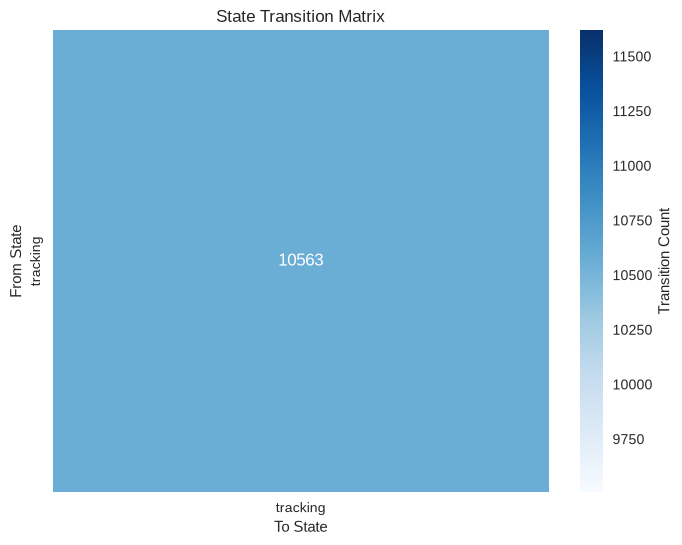

In [129]:
# State transition analysis
state_data = kalman_analysis.analyze_state_transitions(predictions)

print('Transition counts:')
for transition, count in state_data['transition_counts'].items():
    print(f'  {transition}: {count}')

print('State durations (s):')
for state, duration in state_data['state_durations'].items():
    print(f'  {state}: {duration:.2f}')

# Plot transition matrix
if not state_data['state_transition_matrix'].empty:
    fig, ax = kalman_visualizer.plot_state_transition_matrix(state_data['state_transition_matrix'])
    plt.show()

In [130]:
# Velocity vector accuracy
vel_metrics = kalman_analysis.analyze_velocity_vector_accuracy(predictions, opensky)

if vel_metrics:
    print(f'V North RMSE: {vel_metrics["v_north_rmse"]:.4f}')
    print(f'V East RMSE: {vel_metrics["v_east_rmse"]:.4f}')
    print(f'Velocity vector RMSE: {vel_metrics["velocity_vector_rmse"]:.4f}')

V North RMSE: 40.3966
V East RMSE: 42.9292
Velocity vector RMSE: 41.6821


,callsign,frame_index,timestamp_pred,session_id_pred,latitude_pred,longitude_pred,baro_altitude_pred,velocity_pred,true_track_pred,vertical_rate_pred,covariance_lat,covariance_lon,covariance_alt,state,v_north_pred,v_east_pred,timestamp_os,session_id_os,latitude_os,longitude_os,baro_altitude_os,velocity_os,true_track_os,vertical_rate_os,on_ground,v_north_os,v_east_os,lat_delta_deg,lon_delta_deg,alt_delta_m,horizontal_distance_m
0,AEA42DP,2,1.787840e+09,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,43.410275,0.823928,11582.400000,283.07,53.8,0.0,1.466524e-07,2.778518e-07,966.431769,tracking,167.182746,228.426256,1.787840e+09,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,43.4059,0.8157,11582.40,283.07,53.80,0.0,False,167.182746,228.426256,-0.004375,-0.008228,0.000000,0.823721
1,AEA42DP,3,1.787840e+09,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,43.413285,0.829589,11582.400000,283.07,53.8,0.0,3.999289e-07,7.577167e-07,2532.226664,tracking,167.182746,228.426256,1.787840e+09,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,43.4059,0.8157,11582.40,283.07,53.80,0.0,False,167.182746,228.426256,-0.007385,-0.013889,0.000000,1.390340
2,AEA42DP,4,1.787840e+09,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,43.416300,0.835260,11582.400000,283.07,53.8,0.0,7.836692e-07,1.484762e-06,4904.568816,tracking,167.182746,228.426256,1.787840e+09,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,43.4059,0.8157,11582.40,283.07,53.80,0.0,False,167.182746,228.426256,-0.010400,-0.019560,0.000000,1.957982
3,AEA42DP,5,1.787840e+09,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,43.419312,0.840925,11582.400000,283.07,53.8,0.0,1.296920e-06,2.457181e-06,8077.562756,tracking,167.182746,228.426256,1.787840e+09,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,43.4059,0.8157,11582.40,283.07,53.80,0.0,False,167.182746,228.426256,-0.013412,-0.025225,0.000000,2.525011
4,AEA42DP,6,1.787840e+09,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,43.422325,0.846590,11582.400000,283.07,53.8,0.0,1.940121e-06,3.675808e-06,12053.932507,tracking,167.182746,228.426256,1.787840e+09,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,43.4059,0.8157,11582.40,283.07,53.80,0.0,False,167.182746,228.426256,-0.016425,-0.030890,0.000000,3.092106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9681,WZZ985,287,1.787840e+09,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,43.296644,1.018162,10667.238761,190.50,218.2,0.0,4.324039e-07,8.269406e-07,2723.687812,tracking,-149.705738,-117.806799,1.787840e+09,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,42.9418,0.5860,10660.38,184.85,223.65,0.0,False,-133.751874,-127.592942,-0.354844,-0.432162,-6.858761,52.793741
9682,WZZ985,288,1.787840e+09,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,43.293948,1.015228,10667.238761,190.50,218.2,0.0,8.290017e-07,1.585405e-06,5175.517113,tracking,-149.705738,-117.806799,1.787840e+09,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,42.9418,0.5860,10660.38,184.85,223.65,0.0,False,-133.751874,-127.592942,-0.352148,-0.429228,-6.858761,52.412020
9683,WZZ985,289,1.787840e+09,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,43.291244,1.012285,10667.238761,190.50,218.2,0.0,1.357185e-06,2.595516e-06,8440.826877,tracking,-149.705738,-117.806799,1.787840e+09,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,42.9418,0.5860,10660.38,184.85,223.65,0.0,False,-133.751874,-127.592942,-0.349444,-0.426285,-6.858761,52.029090
9684,WZZ985,290,1.787840e+09,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,43.288544,1.009346,10667.238761,190.50,218.2,0.0,2.014823e-06,3.853200e-06,12506.448192,tracking,-149.705738,-117.806799,1.787840e+09,0a8fa20f-13a9-47c5-866c-03bb93ffafb6,42.9418,0.5860,10660.38,184.85,223.65,0.0,False,-133.751874,-127.592942,-0.346744,-0.423346,-6.858761,51.646732


/tmp/ipykernel_42677/2092949565.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)


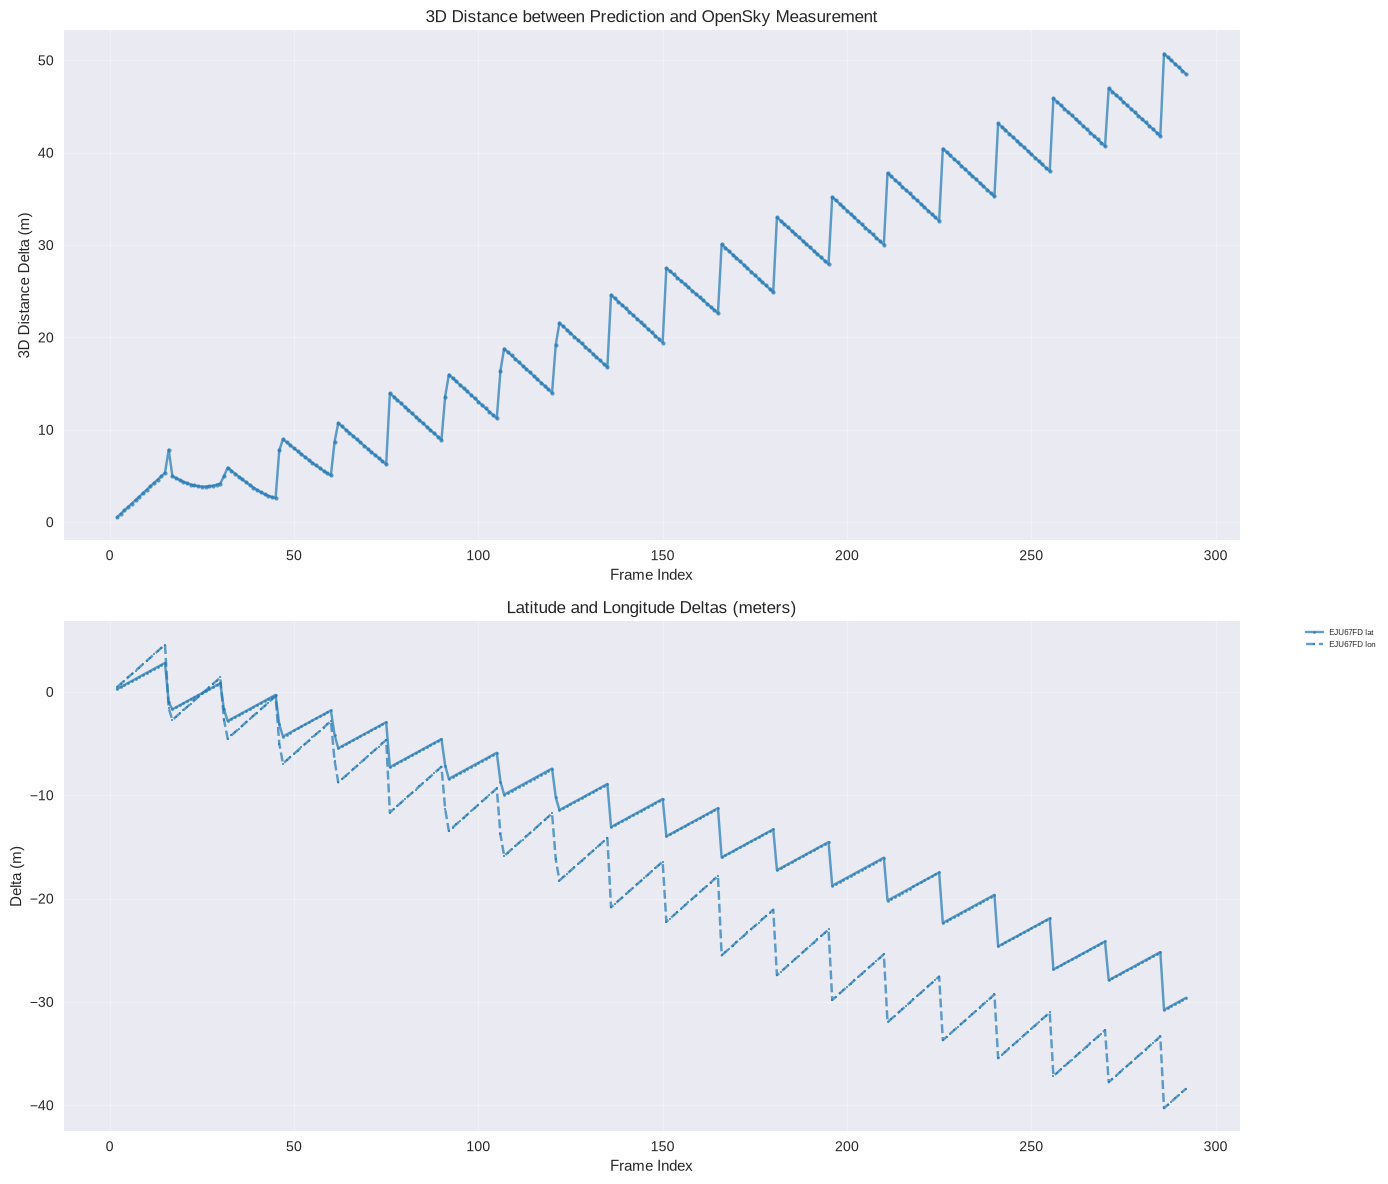

Number of matched (prediction, measurement) pairs: 9686
Unique aircraft: 51

3D Distance Delta Statistics:
  Mean: 199.42 m
  Median: 35.29 m
  Std: 435.28 m
  Min: 0.06 m
  Max: 3226.16 m

Horizontal Distance Statistics:
  Mean: 18.32 m
  Median: 14.22 m

Altitude Delta Statistics:
  Mean: 84.87 m
  Median: 0.00 m
  Std: 470.58 m


In [131]:
# Prediction vs Measurement Distance Delta Analysis
# Calculate the distance between latest predictions and latest OpenSky measurements

import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    # Earth radius in meters
    R = 6371.0
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

# Match predictions with OpenSky data by callsign and frame_index
# Get latest predictions and measurements for each aircraft at each frame
latest_preds = predictions.sort_values(['frame_index', 'timestamp']).groupby(['callsign', 'frame_index']).last().reset_index()
latest_os = opensky.sort_values(['frame_index', 'timestamp']).groupby(['callsign', 'frame_index']).last().reset_index()

# Merge on callsign and frame_index
merged = pd.merge(latest_preds, latest_os, on=['callsign', 'frame_index'], suffixes=('_pred', '_os'), how='inner')
# print("merged", merged)
if len(merged) > 0:
    # Calculate deltas
    merged['lat_delta_deg'] = merged['latitude_os'] - merged['latitude_pred']
    merged['lon_delta_deg'] = merged['longitude_os'] - merged['longitude_pred']
    merged['alt_delta_m'] = merged['baro_altitude_os'] - merged['baro_altitude_pred']

    # Calculate horizontal distance using haversine (in meters)
    merged['horizontal_distance_m'] = haversine_distance(
        merged['latitude_pred'].values, merged['longitude_pred'].values,
        merged['latitude_os'].values, merged['longitude_os'].values
    )

    display(merged)
    # Calculate 3D distance (in meters)
    merged['distance_3d_m'] = np.sqrt(merged['horizontal_distance_m']**2 + merged['alt_delta_m']**2)

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

    # Plot 1: 3D Distance Delta over frames
    # Plot each aircraft with a different color
 
    cmap = plt.cm._colormaps.get_cmap('tab20')
    colors = cmap(np.linspace(0, 1, 1))
    selected_color = colors[0]
    callsign_data = merged[merged['callsign'] == selected_callsign]
    ax1.plot(callsign_data['frame_index'], callsign_data['distance_3d_m'], marker='o', markersize=3, alpha=0.7, color=selected_color)

    ax1.set_xlabel('Frame Index')
    ax1.set_ylabel('3D Distance Delta (m)')
    ax1.set_title('3D Distance between Prediction and OpenSky Measurement')
    ax1.grid(True, alpha=0.3)
    if len(selected_callsign) <= 20:
        ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    else:
        print(f'Skipping legend for {len(selected_callsign)} aircraft (too many for clear display)')

    # Plot 2: Latitude and Longitude Deltas (converted to meters)
    # callsign_data = merged[merged['callsign'] == selected_callsign]
    avg_lat = callsign_data['latitude_os'].mean()
    # Convert degrees to meters (111320 m per degree of lat, lon varies with latitude)
    lat_meters = callsign_data['lat_delta_deg'] * 111320
    lon_meters = callsign_data['lon_delta_deg'] * 111320 * np.cos(np.radians(avg_lat))
    ax2.plot(callsign_data['frame_index'], lat_meters/1000,
            marker='o', markersize=2, alpha=0.7, color=selected_color, label=f'{selected_callsign} lat')
    ax2.plot(callsign_data['frame_index'], lon_meters/1000,
            marker='s', markersize=2, alpha=0.7, color=selected_color, linestyle='--', label=f'{selected_callsign} lon')

    ax2.set_xlabel('Frame Index')
    ax2.set_ylabel('Delta (m)')
    ax2.set_title('Latitude and Longitude Deltas (meters)')
    ax2.grid(True, alpha=0.3)
    if len(selected_callsign) <= 10:
        ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)
    else:
        print(f'Skipping legend for {len(selected_callsign)} aircraft (too many for clear display)')

    plt.tight_layout()
    plt.show()

    # Print statistics
    print(f'Number of matched (prediction, measurement) pairs: {len(merged)}')
    print(f'Unique aircraft: {merged["callsign"].nunique()}')
    print(f'\n3D Distance Delta Statistics:')
    print(f'  Mean: {merged["distance_3d_m"].mean():.2f} m')
    print(f'  Median: {merged["distance_3d_m"].median():.2f} m')
    print(f'  Std: {merged["distance_3d_m"].std():.2f} m')
    print(f'  Min: {merged["distance_3d_m"].min():.2f} m')
    print(f'  Max: {merged["distance_3d_m"].max():.2f} m')
    print(f'\nHorizontal Distance Statistics:')
    print(f'  Mean: {merged["horizontal_distance_m"].mean():.2f} m')
    print(f'  Median: {merged["horizontal_distance_m"].median():.2f} m')
    print(f'\nAltitude Delta Statistics:')
    print(f'  Mean: {merged["alt_delta_m"].mean():.2f} m')
    print(f'  Median: {merged["alt_delta_m"].median():.2f} m')
    print(f'  Std: {merged["alt_delta_m"].std():.2f} m')
else:
    print('No matching prediction-measurement pairs found')

## 5. Statistical Analysis

Aircraft counts, prediction rates, and stability metrics.

In [132]:
# Aircraft count over time
count_data = kalman_analysis.analyze_aircraft_count(statistics)

if len(count_data) > 0:
    fig, ax = kalman_visualizer.plot_aircraft_count(count_data)
    plt.show()
    
    print(f'Max count: {count_data["count"].max():.0f}')
    print(f'Mean count: {count_data["count"].mean():.1f}')
else:
    print('No aircraft count data')

No aircraft count data


In [133]:
# Prediction measurement rates
rate_data = kalman_analysis.analyze_prediction_measurement_rates(statistics)

if rate_data:
    print(f'Avg time between frames: {rate_data["avg_time_between_frames"]:.4f}s')
    print(f'Avg predictions per frame: {rate_data["avg_predictions_per_frame"]:.2f}')
    print(f'Total predictions: {rate_data["total_predictions"]}')
    print(f'Total measurements: {rate_data["total_measurements"]}')

In [134]:
# Track stability metrics
stability = kalman_analysis.calculate_track_stability_metrics(predictions)

if stability:
    print(f'Avg position jump: {stability["avg_position_jump_m"]:.2f}m')
    print(f'Max position jump: {stability["max_position_jump_m"]:.2f}m')
    print(f'Large jumps (>1km): {stability["large_jumps_count"]}')

Avg position jump: 504.23m
Max position jump: 4481.76m
Large jumps (>1km): 600


In [135]:
# Altitude distribution
alt_data = kalman_analysis.analyze_altitude_distribution(predictions)

if alt_data:
    print(f'Mean altitude: {alt_data["mean_altitude_m"]:.2f}m')
    print(f'Max altitude: {alt_data["max_altitude_m"]:.2f}m')
    print(f'Max climb rate: {alt_data["max_climb_rate_mps"]:.2f}m/s')
    print(f'Max descent rate: {alt_data["max_descent_rate_mps"]:.2f}m/s')

Mean altitude: 8560.01m
Max altitude: 12527.28m
Max climb rate: 375.26m/s
Max descent rate: -228.32m/s


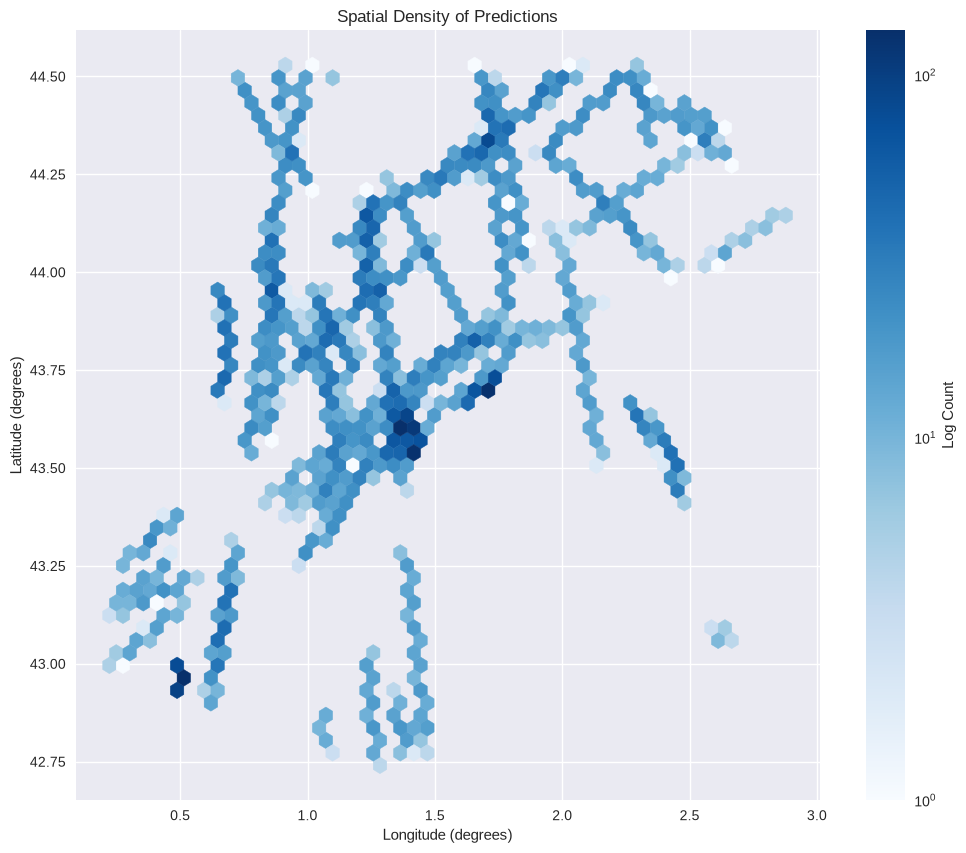

In [136]:
# Spatial density heatmap
if len(predictions) > 0:
    fig, ax = kalman_visualizer.plot_spatial_density_heatmap(predictions, bins=50)
    plt.show()

## 6. Temporal Analysis

Update intervals, timing consistency, and anomalies.

In [137]:
# Update interval analysis
if len(statistics) > 0:
    interval_data = kalman_analysis.analyze_update_intervals(statistics)
else:
    mock_stats = predictions.groupby('timestamp').size().reset_index(name='track_count')
    mock_stats['prediction_count'] = mock_stats['track_count']
    mock_stats['total_predictions'] = mock_stats['track_count'].cumsum()
    mock_stats['total_measurements'] = mock_stats['track_count'].cumsum()
    mock_stats['frame_index'] = range(len(mock_stats))
    mock_stats['session_id'] = predictions['session_id'].iloc[0]
    display(mock_stats)
    interval_data = kalman_analysis.analyze_update_intervals(mock_stats)

if interval_data:
    print(f'Mean interval: {interval_data["mean_interval_s"]:.4f}s')
    print(f'Std interval: {interval_data["std_interval_s"]:.4f}s')
    print(f'Intervals > 1s: {interval_data["intervals_greater_than_1s"]}')
    print(f'Intervals > 5s: {interval_data["intervals_greater_than_5s"]}')

,timestamp,track_count,prediction_count,total_predictions,total_measurements,frame_index,session_id
0,1.787840e+09,31,31,31,31,0,0a8fa20f-13a9-47c5-866c-03bb93ffafb6
1,1.787840e+09,31,31,62,62,1,0a8fa20f-13a9-47c5-866c-03bb93ffafb6
2,1.787840e+09,31,31,93,93,2,0a8fa20f-13a9-47c5-866c-03bb93ffafb6
3,1.787840e+09,31,31,124,124,3,0a8fa20f-13a9-47c5-866c-03bb93ffafb6
4,1.787840e+09,31,31,155,155,4,0a8fa20f-13a9-47c5-866c-03bb93ffafb6
...,...,...,...,...,...,...,...
302,1.787840e+09,39,39,10497,10497,302,0a8fa20f-13a9-47c5-866c-03bb93ffafb6
303,1.787840e+09,39,39,10536,10536,303,0a8fa20f-13a9-47c5-866c-03bb93ffafb6
304,1.787840e+09,39,39,10575,10575,304,0a8fa20f-13a9-47c5-866c-03bb93ffafb6
305,1.787840e+09,39,39,10614,10614,305,0a8fa20f-13a9-47c5-866c-03bb93ffafb6


Mean interval: 2.0006s
Std interval: 0.0003s
Intervals > 1s: 306
Intervals > 5s: 0


In [138]:
# Timing consistency
if len(statistics) > 0:
    timing = kalman_analysis.analyze_frame_timing_consistency(statistics)
else:
    timing = kalman_analysis.analyze_frame_timing_consistency(mock_stats)

if timing:
    print(f'Expected interval: {timing["expected_interval_s"]:.4f}s')
    print(f'Jitter coefficient: {timing["jitter_coefficient"]:.2%}')

Expected interval: 2.0006s
Jitter coefficient: 0.02%


Anomalous intervals: 3


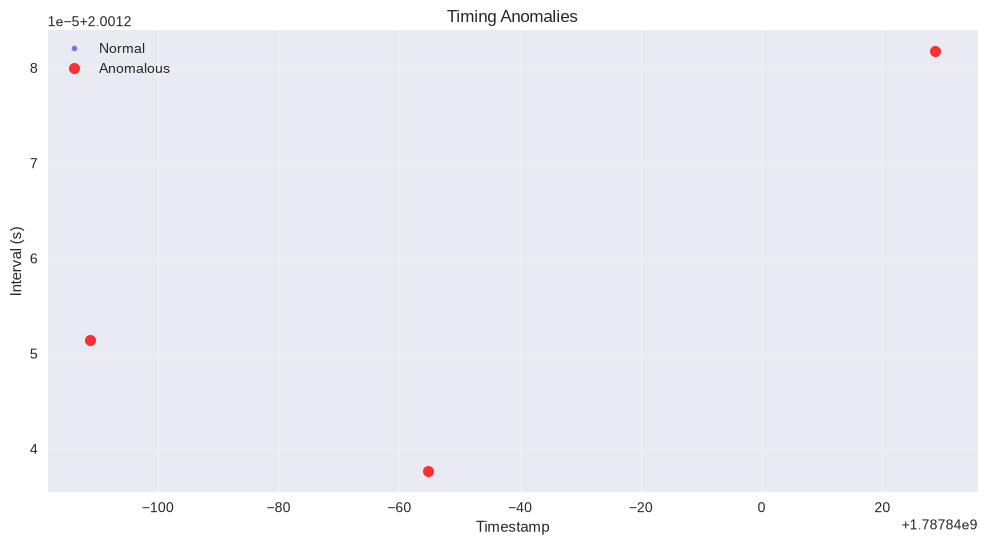

In [139]:
# Timing anomalies
if len(statistics) > 0:
    anomalies = kalman_analysis.identify_timing_anomalies(statistics)
else:
    anomalies = kalman_analysis.identify_timing_anomalies(mock_stats)

print(f'Anomalous intervals: {len(anomalies)}')

if len(anomalies) > 0:
    fig, ax = kalman_visualizer.plot_timing_anomalies(anomalies)
    plt.show()

## 7. Configuration Analysis

Compare configurations and generate tuning recommendations.

In [140]:
# Compare configurations
config_comp = kalman_analysis.compare_configurations(metadata_list)

print(f'Unique configurations: {config_comp["unique_configs"]}')

for i, config in enumerate(config_comp['configurations']):
    print(f'\nConfig {i+1}: {config["session_count"]} sessions')
    print(f'  Process Noise: {config["position_process_noise"]}')
    print(f'  Measurement Noise: {config["position_measurement_noise"]}')

Unique configurations: 1

Config 1: 1 sessions
  Process Noise: 100.0
  Measurement Noise: 20.0


In [141]:
# Generate recommendations
recommendations = kalman_analysis.generate_configuration_recommendations(
    predictions, opensky, metadata_list
)

print('=== Configuration Recommendations ===')
if recommendations:
    for param, rec in recommendations['recommendations'].items():
        priority = recommendations['priority'].get(param, 'LOW')
        print(f'\n[{priority}] {param}: {rec}')

=== Configuration Recommendations ===

[HIGH] position_process_noise: Increase position process noise to allow for more uncertainty in position changes

[HIGH] altitude_process_noise: Altitude process noise appears adequate

[MEDIUM] velocity_process_noise: Velocity process noise appears adequate

[HIGH] measurement_noise: Increase measurement noise to account for higher measurement uncertainty


In [142]:
# Process noise impact
noise_data = kalman_analysis.analyze_process_noise_impact(predictions, metadata_list)

if noise_data:
    print('Process noise levels:', noise_data['noise_levels'])
    for noise, metrics in noise_data['metrics'].items():
        print(f'Noise={noise}: Avg Lat Cov={metrics["avg_covariance_lat"]:.2e}')

Process noise levels: [100.0]
Noise=100.0: Avg Lat Cov=7.38e-06


## 8. Next Steps

### What to do next:

1. Review analysis results and recommendations
2. Tune Kalman filter parameters based on recommendations
3. Run new capture sessions with updated configurations
4. Re-run this notebook to compare performance

### Resources:

- [Kalman Filter Theory](https://en.wikipedia.org/wiki/Kalman_filter)
- TURRET Documentation

---

**Notebook Version**: 1.0.0 | **Last Updated**: 2026-08-24